In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score)

import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")


df = pd.read_csv('/content/MFG10YearTerminationData.csv')

# print the dataset

print(f" dataframe head : {df.head()}")
print(f" dataframe shape : {df.shape}")
print(f" dataframe info : {df.info()}")

# handling null values

print(f"null values : {df.isnull().sum()}")

print(f"columns : {df.columns}")

 dataframe head :    EmployeeID   recorddate_key birthdate_key orighiredate_key  \
0        1318  12/31/2006 0:00      1/3/1954        8/28/1989   
1        1318  12/31/2007 0:00      1/3/1954        8/28/1989   
2        1318  12/31/2008 0:00      1/3/1954        8/28/1989   
3        1318  12/31/2009 0:00      1/3/1954        8/28/1989   
4        1318  12/31/2010 0:00      1/3/1954        8/28/1989   

  terminationdate_key  age  length_of_service  city_name department_name  \
0            1/1/1900   52                 17  Vancouver       Executive   
1            1/1/1900   53                 18  Vancouver       Executive   
2            1/1/1900   54                 19  Vancouver       Executive   
3            1/1/1900   55                 20  Vancouver       Executive   
4            1/1/1900   56                 21  Vancouver       Executive   

  job_title  store_name gender_short gender_full termreason_desc  \
0       CEO          35            M        Male  Not Applicable  

In [ ]:
# xgboost model

neg_count = y_train.value_counts()[0]
pos_count = y_train.value_counts()[1]

scale_pos_weight = neg_count / pos_count

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='auc',
    tree_method='hist',
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight,
     # to make sure weight is equal
    )

xgb_model.fit(x_train, y_train)
y_pred = xgb_model.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"""
accuracy : {accuracy}
precision : {precision}
recall : {recall}
f1_score : {f1}
""")


accuracy : 1.0
precision : 1.0
recall : 1.0
f1_score : 1.0



In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
print(cm)
# generate confusion matrix code

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      1986
         1.0       1.00      1.00      1.00      1985

    accuracy                           1.00      3971
   macro avg       1.00      1.00      1.00      3971
weighted avg       1.00      1.00      1.00      3971

[[1986    0]
 [   0 1985]]


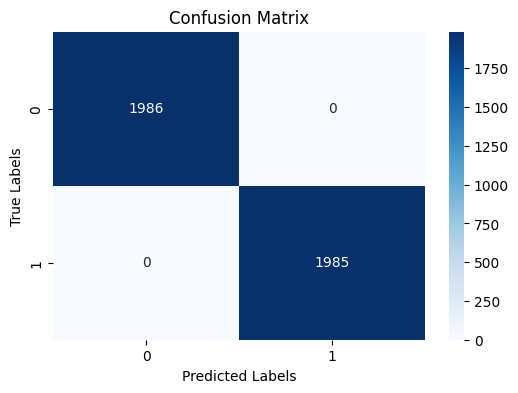

   feature  importance
14     V14    0.636577
12     V12    0.166615
10     V10    0.057075
4       V4    0.029044
11     V11    0.021165
17     V17    0.016489
26     V26    0.015401
29  Amount    0.009798
16     V16    0.008592
15     V15    0.005904
3       V3    0.005064
6       V6    0.004415
23     V23    0.003976
20     V20    0.003655
25     V25    0.002143
22     V22    0.001736
18     V18    0.001517
21     V21    0.001443
28     V28    0.001406
19     V19    0.001355
0     Time    0.001325
5       V5    0.001202
24     V24    0.000948
2       V2    0.000925
13     V13    0.000699
1       V1    0.000673
9       V9    0.000516
7       V7    0.000190
27     V27    0.000150
8       V8    0.000000


['fraud_detection_model.pkl']

In [ ]:
plt.figure(figsize = (6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot = True, fmt = 'd', cmap = 'Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

importance = xgb_model.feature_importances_

feature_importance = pd.DataFrame({'feature': x.columns, 'importance': importance})
print(feature_importance.sort_values(by = 'importance', ascending = False))


import joblib

joblib.dump(xgb_model, "fraud_detection_model.pkl")

In [ ]:
import joblib
joblib.dump(xgb_model, 'fraud_detection_model.pkl')
print(f" saved model as fraud_detection_model.pkl")

 saved model as fraud_detection_model.pkl
